# Titanic Dataset Analysis

### Internship Task 2

This project analyzes the Titanic dataset using **Pandas**, **Matplotlib**, and **Seaborn**. The objective is to clean the dataset, analyze passenger survival, and visualize the results.

In [22]:
import zipfile

with zipfile.ZipFile("titanic.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully!")

Files extracted successfully!


## Import Libraries

The required Python libraries are imported for data analysis and visualization.

- **Pandas**: Data loading and analysis
- **Matplotlib**: Plotting graphs
- **Seaborn**: Statistical data visualization

In [23]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Information

The `info()` function provides information about the dataset, including:

- Number of rows and columns
- Data types
- Non-null values
- Memory usage

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [25]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Check Missing Values

The `isnull().sum()` function is used to identify missing values in each column. This helps determine which columns require data cleaning.

## Data Cleaning

The dataset was cleaned by:

- Filling missing values in the **Age** column using the median.
- Filling missing values in the **Embarked** column using the mode.
- Dropping the **Cabin** column because it contained a large number of missing values.

In [26]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df.drop(columns=["Cabin"], inplace=True)

# Check missing values again
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [27]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [28]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [29]:
survival_gender = df.groupby("Sex")["Survived"].sum()

print(survival_gender)

Sex
female    233
male      109
Name: Survived, dtype: int64


In [30]:
survival_class = df.groupby("Pclass")["Survived"].mean() * 100

print(survival_class)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [31]:
# Create Age Groups
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Calculate Survival Rate
age_survival = df.groupby("Age_Group")["Survived"].mean() * 100

print(age_survival)

Age_Group
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


/tmp/ipykernel_810/1997054628.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("Age_Group")["Survived"].mean() * 100


Age Group Creation:
A new column named Age_Group was created using pd.cut() to categorize passengers into Child, Teen, Young Adult, Adult, and Senior based on their age. This helps analyze survival rates across different age categories.

In [32]:
df[["Age", "Age_Group"]].head(10)

,Age,Age_Group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,28.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teen


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

## Visualization 1: Survival by Gender

This bar chart compares the number of male and female passengers who survived and did not survive the Titanic disaster.

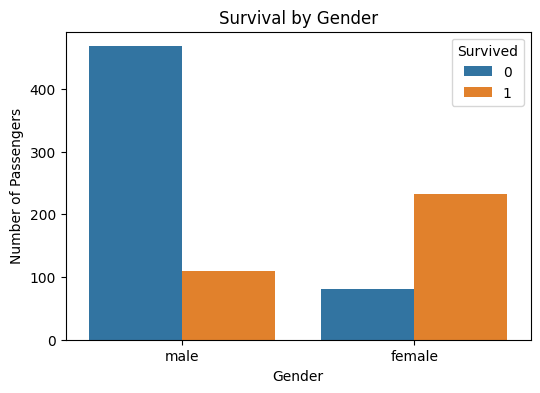

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

- Female passengers had a much higher survival count than male passengers.
- Male passengers had a higher number of deaths.
- This indicates that gender played an important role in survival during the Titanic disaster.

## Visualization 2: Survival by Passenger Class

This bar chart compares the survival of passengers across different passenger classes (1st, 2nd, and 3rd class).

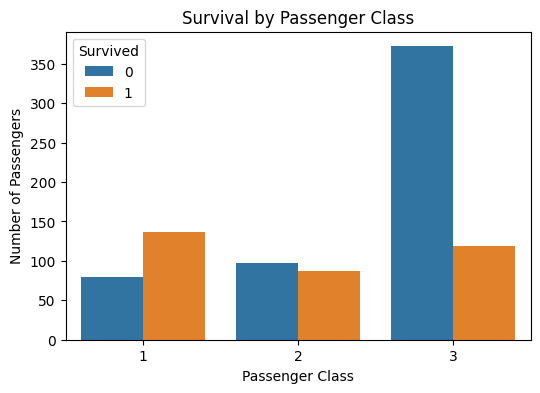

In [35]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

- First-class passengers had the highest number of survivors.
- Third-class passengers had the highest number of deaths.
- Passenger class had a significant impact on survival chances.

## Visualization 3: Distribution of Passenger Ages

The histogram shows how passenger ages are distributed across different age groups.

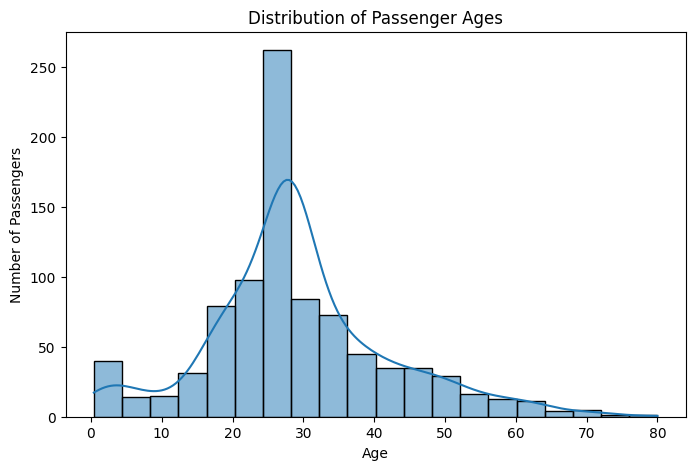

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

- Most passengers were between 20 and 40 years of age.
- There were fewer children and senior passengers.
- The age distribution is concentrated around young adults.

# Conclusion

The Titanic dataset was successfully analyzed using Pandas, Matplotlib, and Seaborn.

Key findings:
- Female passengers had a higher survival rate than male passengers.
- First-class passengers had better survival chances than second- and third-class passengers.
- Passenger age also influenced survival, with younger passengers generally showing better survival rates.

This project demonstrates data loading, cleaning, exploratory data analysis (EDA), and data visualization using Python.